# **Data import and pre-processing**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install datasets



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 17.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 23.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 36.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.20.3
    Uninstalling huggingface-hub-0.20.3:
      Successfully uninstalled huggingface-hub-0.20.3


In [ ]:
# importing data from huggingface

from datasets import load_dataset

dataset = load_dataset("zeroshot/twitter-financial-news-sentiment")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/9543 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2388 [00:00<?, ? examples/s]

In [ ]:
# Storing data into varaibles
train_set = dataset['train']
test_set = dataset['validation']


In [ ]:
# Display the few samples of the training set
print(train_set.features)
print(train_set[:4])


{'text': Value(dtype='string', id=None), 'label': Value(dtype='int64', id=None)}
{'text': ['$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT', '$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3', '$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb', '$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N'], 'label': [0, 0, 0, 0]}


In [ ]:
# count class labels
def count_labels(data):
    label_counts = {}
    for label in data['label']:
        if label in label_counts:
            label_counts[label] += 1
        else:
            label_counts[label] = 1
    return label_counts

# Count labels in training and validation sets
train_label_counts = count_labels(train_set)
test_label_counts = count_labels(test_set)

print("Training Set Label Counts:", train_label_counts)
print("Test Set Label Counts:", test_label_counts)

Training Set Label Counts: {0: 1442, 1: 1923, 2: 6178}
Test Set Label Counts: {0: 347, 1: 475, 2: 1566}


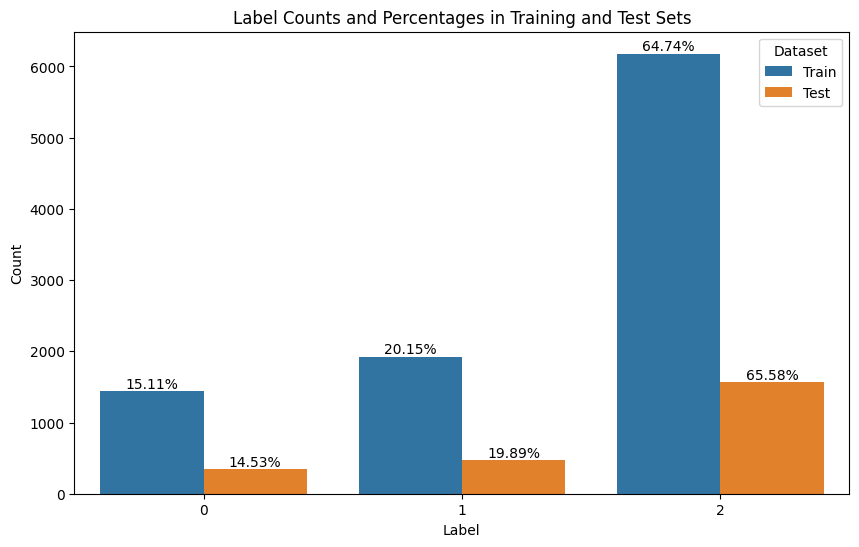

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Creating list of dictionaries from the counts
data_list = []
total_train = sum(train_label_counts.values())  # Total count in train set
total_test = sum(test_label_counts.values())    # Total count in test set

for label, count in train_label_counts.items():
    percent = (count / total_train) * 100  # Calculate percentage
    data_list.append({'Label': label, 'Count': count, 'Percentage': percent, 'Dataset': 'Train'})
for label, count in test_label_counts.items():
    percent = (count / total_test) * 100   # Calculate percentage
    data_list.append({'Label': label, 'Count': count, 'Percentage': percent, 'Dataset': 'Test'})

# Convert to a DataFrame
data_df = pd.DataFrame(data_list)

# Plotting the data
plt.figure(figsize=(10, 6))
ax = plt.subplot()

# Create bar chart
bar = sns.barplot(data=data_df, x='Label', y='Count', hue='Dataset')

# labels and title
plt.title('Label Counts and Percentages in Training and Test Sets')
plt.xlabel('Label')
plt.ylabel('Count')
plt.legend(title='Dataset')

# Annotate percentages on the bars
for p, (label, row) in zip(bar.patches, data_df.iterrows()):
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2
    y = height
    label = f'{row["Percentage"]:.2f}%'
    plt.text(x, y, label, ha='center', va='bottom')

plt.xticks()

# Display the plot
plt.show()


# **Pre-processing**

In [ ]:
# Preprocessing the tweet data using functions

import re
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

def preprocess_tweet(text):
    text = text.lower()                           # lowercasing
    text = re.sub(r'https?://\S+', '', text)      # removing URLs
    text = re.sub(r'@\w+', '', text)              # removing user mentions
    text = re.sub(r'\d+', '', text)               # removing numerical digits
    text = re.sub(r'\W+', ' ', text)              # removing non-alpha numeric characters
    tokenizer = TweetTokenizer()                  # tokenization
    tokens = tokenizer.tokenize(text)
    tokens = [word for word in tokens if word not in stopwords.words('english')] # stop word removal
    lemmatizer = WordNetLemmatizer()              # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return tokens

def preprocess_data(example):
    # Preprocess the text
    processed_text = preprocess_tweet(example['text'])
    # include the label
    return {'text': processed_text, 'label': example['label']}


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
# Apply the preprocessing to each split
processed_datasets_train = train_set.map(preprocess_data)
processed_datasets_test = test_set.map(preprocess_data)


Parameter 'function'=<function preprocess_data at 0x7a328bd7fbe0> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/9543 [00:00<?, ? examples/s]

Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

In [ ]:
# Separate text and labels for train

train_text = processed_datasets_train["text"]
train_label = processed_datasets_train["label"]

# Display some processed data to verify
print(train_text[0:300])
print(train_label[0:300])


[['bynd', 'jpmorgan', 'reel', 'expectation', 'beyond', 'meat'], ['ccl', 'rcl', 'nomura', 'point', 'booking', 'weakness', 'carnival', 'royal', 'caribbean'], ['cx', 'cemex', 'cut', 'credit', 'suisse', 'j', 'p', 'morgan', 'weak', 'building', 'outlook'], ['es', 'btig', 'research', 'cut', 'neutral'], ['fnko', 'funko', 'slide', 'piper', 'jaffray', 'pt', 'cut'], ['fti', 'technipfmc', 'downgraded', 'berenberg', 'called', 'top', 'pick', 'deutsche', 'bank'], ['gm', 'gm', 'loses', 'bull'], ['gm', 'deutsche', 'bank', 'cut', 'hold'], ['gtt', 'cowen', 'cut', 'market', 'perform'], ['hnhaf', 'hnhpd', 'aapl', 'trendforce', 'cut', 'iphone', 'estimate', 'foxconn', 'delay'], ['hog', 'moody', 'warns', 'harley', 'davidson'], ['hxl', 'citing', 'aero', 'tie', 'well', 'slash', 'pt', 'hexcel'], ['intelsat', 'cut', 'market', 'perform', 'raymond', 'james'], ['krg', 'compass', 'point', 'cut', 'sell'], ['lk', 'muddy', 'water', 'go', 'short', 'luckin', 'coffee'], ['mant', 'mantech', 'downgraded', 'ahead', 'difficult

In [ ]:
# Separate text and labels for test

test_text = processed_datasets_test["text"]
test_label = processed_datasets_test["label"]

# Display some processed data to verify
print(test_text[0:300])
print(test_label[0:300])

[['ally', 'ally', 'financial', 'pull', 'outlook'], ['dell', 'hpe', 'dell', 'hpe', 'target', 'trimmed', 'compute', 'headwind'], ['prty', 'moody', 'turn', 'negative', 'party', 'city'], ['san', 'deutsche', 'bank', 'cut', 'hold'], ['sitc', 'compass', 'point', 'cut', 'sell'], ['tap', 'barclays', 'cool', 'molson', 'coors'], ['tap', 'barclays', 'cut', 'equal', 'weight'], ['analyst', 'eviscerate', 'musk', 'cybertruck', 'response', 'felt', 'success'], ['barclays', 'assigns', 'chance', 'study', 'gilead', 'antiviral', 'drug', 'done', 'china', 'succeed'], ['btig', 'point', 'breakfast', 'pressure', 'dunkin', 'brand'], ['child', 'place', 'downgraded', 'neutral', 'outperform', 'wedbush', 'price', 'target', 'slashed'], ['clovis', 'oncology', 'downgraded', 'line', 'outperform', 'evercore', 'isi'], ['downgrade', 'aan', 'bdn', 'becn', 'bte', 'cdev', 'chk', 'coop', 'cpe', 'cva', 'dan', 'doc', 'drh', 'epr', 'esrt', 'etm', 'fast', 'fbm', 'gm', 'gm'], ['goldman', 'pull', 'progressive', 'goldman', 'conviction

# **Save data as text**

In [ ]:
# Saving training data

text_file_path = '/content/drive/My Drive/NLP/NLP_CW/data/train_text.txt'
label_file_path = '/content/drive/My Drive/NLP/NLP_CW/data/train_label.txt'

with open(text_file_path, 'w', encoding='utf-8') as text_file:
    for tokens in processed_datasets_train["text"]:
        text_line = ','.join(tokens)                  # Join tokens with a comma
        text_file.write(text_line + '\n')             # Write the joined tokens followed by a newline

with open(label_file_path, 'w', encoding='utf-8') as label_file:
    for label in processed_datasets_train["label"]:
        label_file.write(str(label) + '\n')


In [ ]:
# Saving testing data

text_file_path = '/content/drive/My Drive/NLP/NLP_CW/data/test_text.txt'
label_file_path = '/content/drive/My Drive/NLP/NLP_CW/data/test_label.txt'

with open(text_file_path, 'w', encoding='utf-8') as text_file:
    for tokens in processed_datasets_test["text"]:
        text_line = ','.join(tokens)        # Join tokens with a comma
        text_file.write(text_line + '\n')   # Write the joined tokens followed by a newline

with open(label_file_path, 'w', encoding='utf-8') as label_file:
    for label in processed_datasets_test["label"]:
        label_file.write(str(label) + '\n')


In [ ]:
# word count of each line of tweet
word_counts = [len(text) for text in train_text]


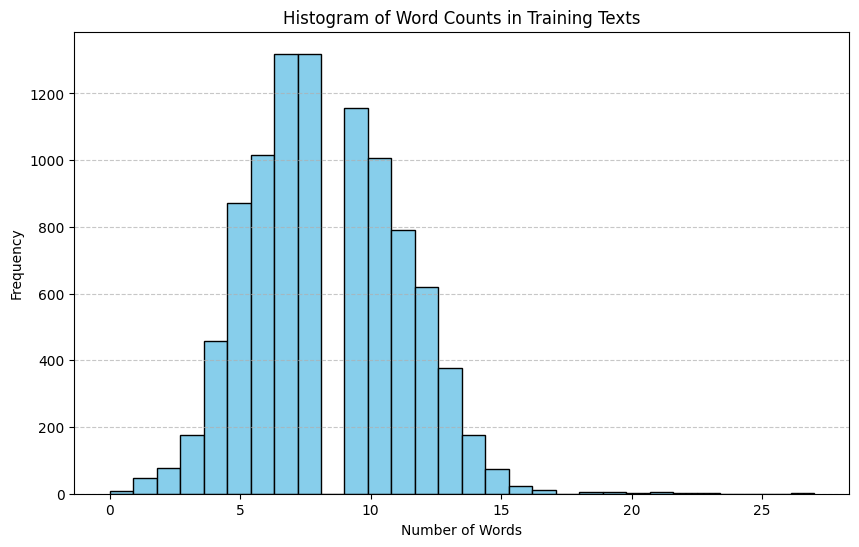

In [ ]:
# plotting the word count frequency

import matplotlib.pyplot as plt

# Plotting the histogram of word counts
plt.figure(figsize=(10, 6))
plt.hist(word_counts, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Word Counts in Training Texts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# **Load the data**

In [ ]:
# loading training data

text_file_path = '/content/drive/My Drive/NLP/NLP_CW/data/train_text.txt'
label_file_path = '/content/drive/My Drive/NLP/NLP_CW/data/train_label.txt'

# Load the text data
with open(text_file_path, 'r', encoding='utf-8') as text_file:
    texts = [line.strip().split(',') for line in text_file]

# Load the labels
with open(label_file_path, 'r', encoding='utf-8') as label_file:
    labels = [int(line.strip()) for line in label_file]

print(train_text[0:300])
print(train_label[0:300])

[['bynd', 'jpmorgan', 'reel', 'expectation', 'beyond', 'meat'], ['ccl', 'rcl', 'nomura', 'point', 'booking', 'weakness', 'carnival', 'royal', 'caribbean'], ['cx', 'cemex', 'cut', 'credit', 'suisse', 'j', 'p', 'morgan', 'weak', 'building', 'outlook'], ['es', 'btig', 'research', 'cut', 'neutral'], ['fnko', 'funko', 'slide', 'piper', 'jaffray', 'pt', 'cut'], ['fti', 'technipfmc', 'downgraded', 'berenberg', 'called', 'top', 'pick', 'deutsche', 'bank'], ['gm', 'gm', 'loses', 'bull'], ['gm', 'deutsche', 'bank', 'cut', 'hold'], ['gtt', 'cowen', 'cut', 'market', 'perform'], ['hnhaf', 'hnhpd', 'aapl', 'trendforce', 'cut', 'iphone', 'estimate', 'foxconn', 'delay'], ['hog', 'moody', 'warns', 'harley', 'davidson'], ['hxl', 'citing', 'aero', 'tie', 'well', 'slash', 'pt', 'hexcel'], ['intelsat', 'cut', 'market', 'perform', 'raymond', 'james'], ['krg', 'compass', 'point', 'cut', 'sell'], ['lk', 'muddy', 'water', 'go', 'short', 'luckin', 'coffee'], ['mant', 'mantech', 'downgraded', 'ahead', 'difficult

In [ ]:
# loading testing data

text_file_path = '/content/drive/My Drive/NLP/NLP_CW/data/test_text.txt'
label_file_path = '/content/drive/My Drive/NLP/NLP_CW/data/test_label.txt'

# Load the text data
with open(text_file_path, 'r', encoding='utf-8') as text_file:
    texts = [line.strip().split(',') for line in text_file]

# Load the labels
with open(label_file_path, 'r', encoding='utf-8') as label_file:
    labels = [int(line.strip()) for line in label_file]

print(test_text[0:300])
print(test_label[0:300])

[['ally', 'ally', 'financial', 'pull', 'outlook'], ['dell', 'hpe', 'dell', 'hpe', 'target', 'trimmed', 'compute', 'headwind'], ['prty', 'moody', 'turn', 'negative', 'party', 'city'], ['san', 'deutsche', 'bank', 'cut', 'hold'], ['sitc', 'compass', 'point', 'cut', 'sell'], ['tap', 'barclays', 'cool', 'molson', 'coors'], ['tap', 'barclays', 'cut', 'equal', 'weight'], ['analyst', 'eviscerate', 'musk', 'cybertruck', 'response', 'felt', 'success'], ['barclays', 'assigns', 'chance', 'study', 'gilead', 'antiviral', 'drug', 'done', 'china', 'succeed'], ['btig', 'point', 'breakfast', 'pressure', 'dunkin', 'brand'], ['child', 'place', 'downgraded', 'neutral', 'outperform', 'wedbush', 'price', 'target', 'slashed'], ['clovis', 'oncology', 'downgraded', 'line', 'outperform', 'evercore', 'isi'], ['downgrade', 'aan', 'bdn', 'becn', 'bte', 'cdev', 'chk', 'coop', 'cpe', 'cva', 'dan', 'doc', 'drh', 'epr', 'esrt', 'etm', 'fast', 'fbm', 'gm', 'gm'], ['goldman', 'pull', 'progressive', 'goldman', 'conviction

# **Feature Extraction with Word2Vec**

In [ ]:
from gensim.models import Word2Vec
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# tokenizzed text variables
tokenized_train_texts = train_text
tokenized_test_texts = test_text

# Train a Word2Vec model
word2vec_model = Word2Vec(sentences=tokenized_train_texts, vector_size=100, window=5, min_count=1, workers=4)

# Function for a feature vector by averaging all word vectors in a document
def document_vector(model, doc):
    # Remove out-of-vocabulary words
    doc = [word for word in doc if word in model.wv.key_to_index]
    if len(doc) == 0:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[doc], axis=0)

# Applying function to each preprocessed tweet in training and test sets
train_features = np.array([document_vector(word2vec_model, doc) for doc in tokenized_train_texts])
test_features = np.array([document_vector(word2vec_model, doc) for doc in tokenized_test_texts])

X_train = train_features
X_test = test_features


In [ ]:
# train and test labels in text format
y_train = train_label
y_test = test_label

In [ ]:
#Converting y-train and y_test labels to array

from sklearn.preprocessing import LabelEncoder

# Convert labels to numpy arrays
if not isinstance(y_train, np.ndarray) or not isinstance(y_test, np.ndarray):
    encoder = LabelEncoder()
    y_train = encoder.fit_transform(y_train)
    y_test = encoder.transform(y_test)
    y_train = np.array(y_train)
    y_test = np.array(y_test)
    print("Converted y_train and y_test to NumPy arrays with type:", y_train.dtype)


Converted y_train and y_test to NumPy arrays with type: int64


# **Baseline Model SVM**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Initialize the SVM classifier
svm_classifier = SVC(random_state=42)

# Train the classifier on the resampled training data
svm_classifier.fit(X_train, y_train)

# Predict the labels for test set
y_pred = svm_classifier.predict(X_test)

# Calculate the accuracy of the predictions
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of SVM classifier on test data:", accuracy)

# Print the classification report to see precision, recall, f1-score
print(classification_report(y_test, y_pred))


Accuracy of SVM classifier on test data: 0.6624790619765494
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       347
           1       0.42      0.06      0.11       475
           2       0.67      0.99      0.80      1566

    accuracy                           0.66      2388
   macro avg       0.36      0.35      0.30      2388
weighted avg       0.52      0.66      0.55      2388



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# **CM Matrix Base Line Model**

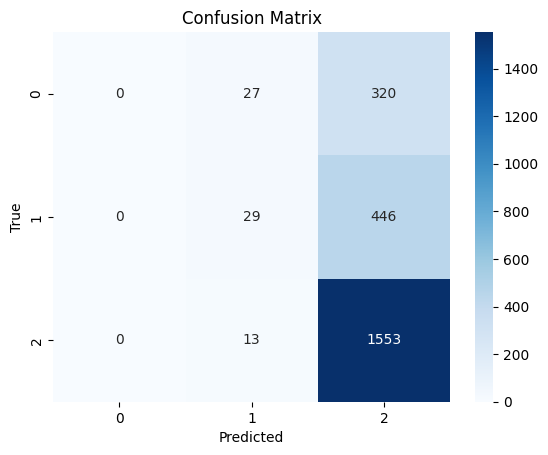

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **Hyper tuning Word2Vec Model**

In [ ]:
from gensim.models import Word2Vec
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

# Param grid for Word2Vec
vector_sizes = [100, 200]
windows = [5, 10]
min_counts = [1, 5]
sg_options = [0, 1]  # 0 for CBOW, 1 for skip-gram

# Function for a feature vector by averaging all word vectors in a document
def document_vector(model, doc):
    doc = [word for word in doc if word in model.wv.key_to_index]
    if len(doc) == 0:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[doc], axis=0)

best_accuracy = 0
best_params = {}

for vector_size in vector_sizes:
    for window in windows:
        for min_count in min_counts:
            for sg in sg_options:
                # Train Word2Vec model
                w2v_model = Word2Vec(sentences=tokenized_train_texts, vector_size=vector_size, window=window,
                                     min_count=min_count, sg=sg, workers=4)

                # Generate features for training and testing data
                train_features = np.array([document_vector(w2v_model, doc) for doc in tokenized_train_texts])
                test_features = np.array([document_vector(w2v_model, doc) for doc in tokenized_test_texts])

                # Train RF Classifier
                clf = RandomForestClassifier(n_estimators=100, random_state=42)
                clf.fit(train_features, train_label)

                # Predict and evaluate
                predictions = clf.predict(test_features)
                accuracy = accuracy_score(test_label, predictions)

                # Store the best parameters and score
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_params = {'vector_size': vector_size, 'window': window,
                                   'min_count': min_count, 'sg': sg, 'model_accuracy': accuracy}

print("Best Accuracy:", best_accuracy)
print("Best Params:", best_params)


Best Accuracy: 0.7365996649916248
Best Params: {'vector_size': 100, 'window': 10, 'min_count': 5, 'sg': 1, 'model_accuracy': 0.7365996649916248}


# **Feature Extraction with HP tuned Word2Vec**

In [ ]:
from gensim.models import Word2Vec
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# train_text and test_text lists
tokenized_train_texts = train_text
tokenized_test_texts = test_text

# Train a Word2Vec model
word2vec_model = Word2Vec(sentences=tokenized_train_texts, vector_size=100, window=10, min_count=5, sg=1)

# Function to create a feature vector by averaging all word vectors in a document
def document_vector(model, doc):
    # Removing out-of-vocabulary words
    doc = [word for word in doc if word in model.wv.key_to_index]
    if len(doc) == 0:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[doc], axis=0)

# Applying the function to each preprocessed tweet in training and test sets
train_features = np.array([document_vector(word2vec_model, doc) for doc in tokenized_train_texts])
test_features = np.array([document_vector(word2vec_model, doc) for doc in tokenized_test_texts])

X_train = train_features
X_test = test_features


# **Word2Vec + RF (base)**

In [ ]:
# Train a simple RF model with features
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Evaluate the model
print("Accuracy on test set:", rf_clf.score(X_test, y_test))

# Predict the labels for the test set and print classification report
y_pred = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred))

Accuracy on test set: 0.742462311557789
              precision    recall  f1-score   support

           0       0.58      0.28      0.38       347
           1       0.59      0.43      0.50       475
           2       0.79      0.94      0.86      1566

    accuracy                           0.74      2388
   macro avg       0.65      0.55      0.58      2388
weighted avg       0.72      0.74      0.71      2388



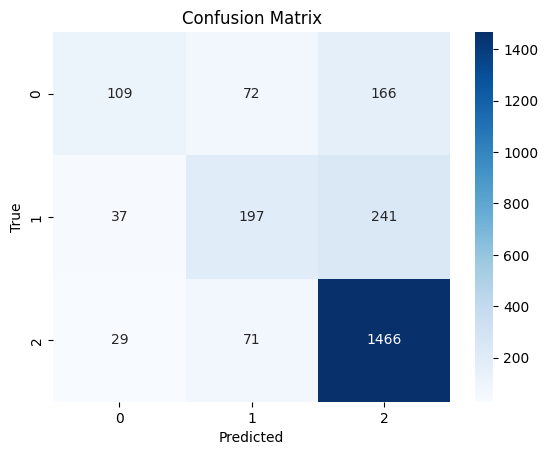

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **HP Tuning of RF Model**

In [ ]:
from sklearn.model_selection import GridSearchCV

# RandomForest parameters to be tuned
param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [20, 40],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 4]
}

# GridSearchCV object
clf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=3, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters and model
print("Best parameters found: ", grid_search.best_params_)



Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Best parameters found:  {'max_depth': 40, 'max_features': 'auto', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}


# **Word2Vec + RF(Hyper tuned)**
### **after hyper parameter tuning both Word2Vec and RF Classifier**

In [ ]:
# train and evaluate the RF classifier model with features extracted from word embeddings
rf_w2v_clf = RandomForestClassifier(n_estimators=100, max_depth = 40, max_features = 'sqrt', min_samples_leaf = 4,
                                    min_samples_split = 2,random_state=42)
rf_w2v_clf.fit(X_train, y_train)

# Evaluate the best model
y_pred = rf_w2v_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.23      0.34       347
           1       0.57      0.41      0.48       475
           2       0.77      0.94      0.85      1566

    accuracy                           0.73      2388
   macro avg       0.65      0.53      0.55      2388
weighted avg       0.71      0.73      0.70      2388



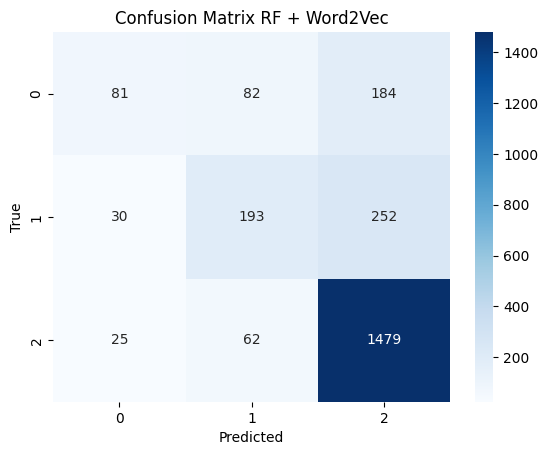

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Plot the confusion matrix
rf_cm = confusion_matrix(y_test, y_pred)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix RF + Word2Vec')
plt.show()


# **Error Analysis**

In [ ]:
import pandas as pd
import numpy as np

# Find misclassified indices
misclassified_indices = np.where(y_pred != y_test)[0]

# Select 50 misclassified samples for analysis
num_samples = min(50, len(misclassified_indices))
selected_indices = np.random.choice(misclassified_indices, num_samples, replace=False)

# Create a DataFrame to show the original text with true and predicted labels
misclassified_samples = pd.DataFrame({
    'Text': [test_text[i] for i in selected_indices],
    'True_Label': y_test[selected_indices],
    'Predicted_Label': y_pred[selected_indices]
})

# Display the misclassified examples
print("Misclassified Examples (with Original Text):")
print(misclassified_samples.to_string(index=False))


Misclassified Examples (with Original Text):
                                                                                                   Text  True_Label  Predicted_Label
                                            [umich, consumer, confidence, surge, early, december, read]           1                2
                             [update, european, stock, end, flat, defensive, gain, offset, auto, slide]           2                1
                     [south, africa, rand, firmer, risk, taker, return, stock, economy, marketscreener]           1                2
                                                                         [zogenix, took, tumble, today]           0                2
                                        [ethereum, eth, price, may, soon, surge, ethereum, world, news]           1                2
            [dual, shock, saudi, russian, oil, price, war, covid, pandemic, could, put, albertans, wor]           0                2
             [amzn, amaz

# **Word2Vec + DT base Model**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn import tree

clf = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the Decision Tree Classifier
clf.fit(X_train, y_train)

# Predict the response for the test dataset
y_pred = clf.predict(X_test)

# Evaluating the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6809045226130653
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       347
           1       0.44      0.25      0.32       475
           2       0.71      0.96      0.82      1566

    accuracy                           0.68      2388
   macro avg       0.38      0.40      0.38      2388
weighted avg       0.55      0.68      0.60      2388



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


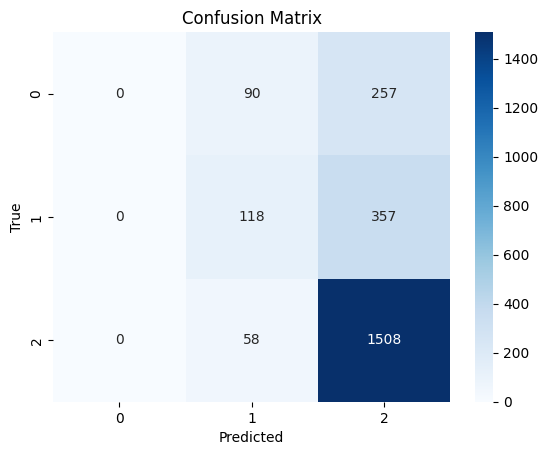

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **DT HyperTuning**

In [ ]:
# DT Classifier hyper tuning with hyperparameters using resampled training data

dt = DecisionTreeClassifier(random_state=42)

# Create the parameter grid
param_grid = {
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Setup the grid search
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, verbose=1, scoring='accuracy')

# Fit grid search
grid_search.fit(X_train, y_train)

# Best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validated score: ", grid_search.best_score_)



Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best cross-validated score:  0.5901684945963784


# **Word2Vec + DT (Hyper tuned)**

In [ ]:
# Retrain the model with DT Classifier and features extracted using word embeddings

dt_w2v_clf = DecisionTreeClassifier(max_depth=10, criterion='gini', min_samples_leaf=4, min_samples_split=2, random_state=42)

# Train the Decision Tree Classifier
dt_w2v_clf.fit(X_train, y_train)

# Predict the response for the test dataset
y_pred = dt_w2v_clf.predict(X_test)

# Evaluating the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6750418760469011
Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.22      0.27       347
           1       0.46      0.40      0.42       475
           2       0.76      0.86      0.81      1566

    accuracy                           0.68      2388
   macro avg       0.53      0.49      0.50      2388
weighted avg       0.64      0.68      0.65      2388



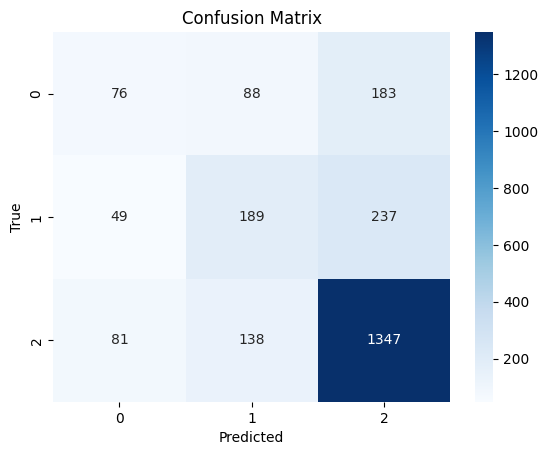

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
dt_cm = confusion_matrix(y_test, y_pred)
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **Save Model**

In [ ]:
# from joblib import dump

# # Save the model to a file
# filepath = '/content/drive/MyDrive/NLP/NLP_CW/model/rf_Clf.joblib'
# dump(rf_clf, filepath)


# **N-gram with range of (1, 3)**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# text data variables and their labels
X_train = train_text
X_test = test_text

# label variables are imported from previous section which remains array
y_train = y_train
y_test = y_test

In [ ]:
# Restoring the training and testing datasets

X_train, X_test, y_train, y_test = (X_train, X_test, y_train, y_test)


In [ ]:
#  Convert Tokenized Text Back to Strings
X_train = [' '.join(doc) for doc in train_text]
X_test = [' '.join(doc) for doc in test_text]

# apply CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer with Specific N-gram Range
# This parameter tells the vectorizer to consider unigrams (single words),
# bigrams (two consecutive words), and trigrams (three consecutive words)
vectorizer = CountVectorizer(ngram_range=(1, 3))

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)


# **N-gram + RF (base)**

In [ ]:
# Train RF Classifier model with features extracted using ngrams
rf_ngram_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ngram_clf.fit(X_train, y_train)

# Evaluate the model
print("Accuracy on test set:", rf_ngram_clf.score(X_test, y_test))

# Predict the labels for the test set and print classification report
y_pred = rf_ngram_clf.predict(X_test)
print(classification_report(y_test, y_pred))

Accuracy on test set: 0.7956448911222781
              precision    recall  f1-score   support

           0       0.84      0.37      0.51       347
           1       0.78      0.56      0.65       475
           2       0.80      0.96      0.87      1566

    accuracy                           0.80      2388
   macro avg       0.80      0.63      0.68      2388
weighted avg       0.80      0.80      0.77      2388



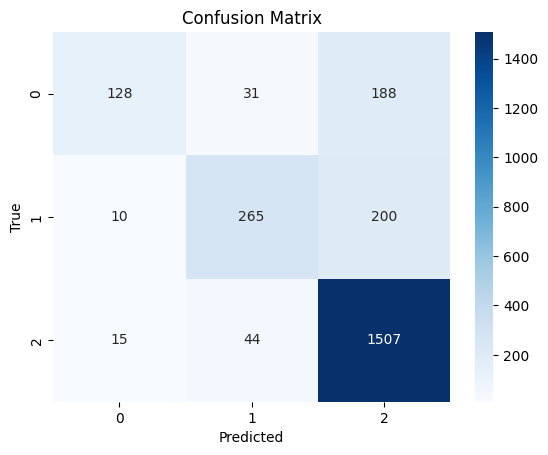

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **RF Hypertuning**

In [ ]:
from sklearn.model_selection import GridSearchCV

# Assuming RandomForest parameters to be tuned
param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [20, 40],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 4]
}

# Create a GridSearchCV object
clf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=3, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters and model
print("Best parameters found: ", grid_search.best_params_)



Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Best parameters found:  {'max_depth': 40, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


#**N-gram + RF (Hyper tuned)**

In [ ]:
# Train a simple model (e.g., Random Forest)
rf_bigram_clf_best = RandomForestClassifier(n_estimators=100, max_depth = 40, max_features = 'sqrt',
                                            min_samples_leaf = 1, min_samples_split = 5, random_state=42)
rf_bigram_clf_best.fit(X_train, y_train)

# Evaluate the model
print("Accuracy on test set:", rf_bigram_clf_best.score(X_test, y_test))

# Predict the labels for the test set and print classification report
y_pred = rf_bigram_clf_best.predict(X_test)
print(classification_report(y_test, y_pred))

Accuracy on test set: 0.6855108877721943
              precision    recall  f1-score   support

           0       1.00      0.05      0.10       347
           1       1.00      0.11      0.20       475
           2       0.68      1.00      0.81      1566

    accuracy                           0.69      2388
   macro avg       0.89      0.39      0.37      2388
weighted avg       0.79      0.69      0.58      2388



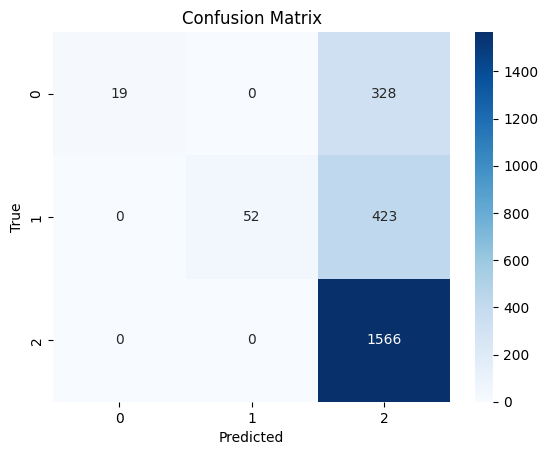

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **N-gram + DT (base)**

In [ ]:
# Basic DT Classifier model testing

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn import tree

clf = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the Decision Tree Classifier
clf.fit(X_train, y_train)

# Predict the response for the test dataset
y_pred = clf.predict(X_test)

# Evaluating the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6930485762144054
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.08      0.15       347
           1       0.92      0.14      0.25       475
           2       0.68      1.00      0.81      1566

    accuracy                           0.69      2388
   macro avg       0.83      0.41      0.40      2388
weighted avg       0.76      0.69      0.60      2388



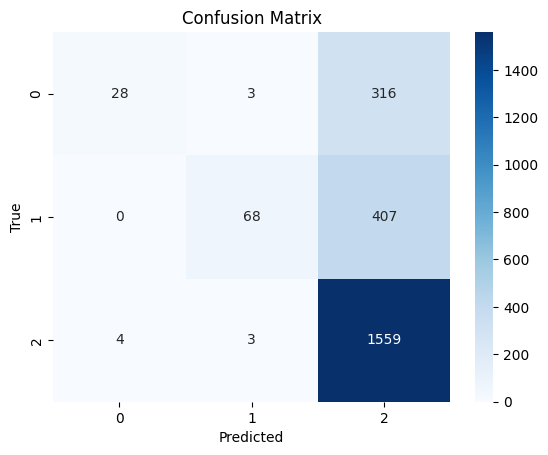

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **DT HP tuning**

In [ ]:
# Hyper tuning DT Classifier using resampled training data

dt = DecisionTreeClassifier(random_state=42)

# Create the parameter grid
param_grid = {
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Setup the grid search
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, verbose=1, scoring='accuracy')

# Fit grid search
grid_search.fit(X_train, y_train)

# Best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validated score: ", grid_search.best_score_)



Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-validated score:  0.6612151641842183


# **N-gram + DT (Hyper tuned)**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_ngram_clf = DecisionTreeClassifier(max_depth=30, criterion='gini', min_samples_leaf=1, min_samples_split = 5, random_state=42)

# Train the Decision Tree Classifier using resampled features data
dt_ngram_clf.fit(X_train, y_train)

# Predict the response for the test dataset
y_pred = dt_ngram_clf.predict(X_test)

# Evaluating the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7634003350083752
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.31      0.43       347
           1       0.75      0.46      0.57       475
           2       0.77      0.96      0.85      1566

    accuracy                           0.76      2388
   macro avg       0.74      0.58      0.62      2388
weighted avg       0.76      0.76      0.74      2388



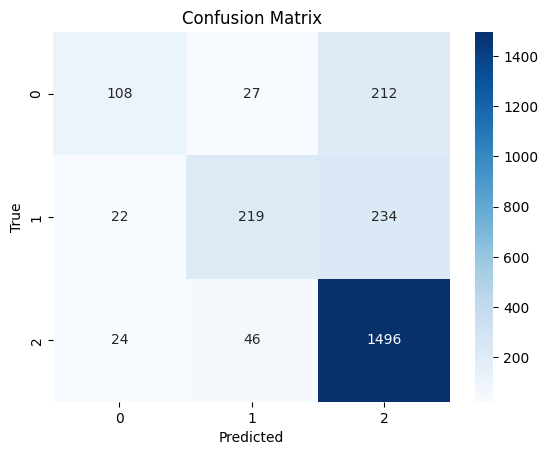

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **Save Model**

In [ ]:
from joblib import dump

# Save the model to a file
filepath = '/content/drive/MyDrive/NLP/NLP_CW/model/dt_ngram_clf.joblib'
dump(dt_ngram_clf, filepath)


['/content/drive/MyDrive/NLP/NLP_CW/model/dt_ngram_clf.joblib']

# **error analysis**

In [ ]:
import pandas as pd
import numpy as np

# Find misclassified indices
misclassified_indices = np.where(y_pred != y_test)[0]

# Select 50 misclassified samples for analysis
num_samples = min(50, len(misclassified_indices))
selected_indices = np.random.choice(misclassified_indices, num_samples, replace=False)

# Create a DataFrame to show the original text with true and predicted labels
misclassified_samples = pd.DataFrame({
    'Text': [test_text[i] for i in selected_indices],
    'True_Label': y_test[selected_indices],
    'Predicted_Label': y_pred[selected_indices]
})

# Display the misclassified examples
print("Misclassified Examples (with Original Text):")
print(misclassified_samples.to_string(index=False))


Misclassified Examples (with Original Text):
                                                                                                  Text  True_Label  Predicted_Label
                                             [air, passenger, growth, return, double, digit, november]           1                2
                                                   [texas, manufacturing, activity, weakens, slightly]           0                2
                                                                             [livexlive, samsung, tie]           1                2
                                                                           [bill, com, trading, debut]           1                2
                                     [arch, coal, rated, buy, benchmark, seeing, opportunity, selloff]           1                2
                         [pete, buttigieg, see, surge, support, business, exec, strong, showing, iowa]           2                1
                               

# **N-gram + TFIDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# load data function
def load_data(text_file_path, label_file_path):
    with open(text_file_path, 'r', encoding='utf-8') as file:
        texts = [line.strip() for line in file]
    with open(label_file_path, 'r', encoding='utf-8') as file:
        labels = [int(line.strip()) for line in file]
    return texts, labels

# Load training data
train_text_path = '/content/drive/My Drive/NLP/NLP_CW/data/train_text.txt'
train_label_path = '/content/drive/My Drive/NLP/NLP_CW/data/train_label.txt'
train_texts, train_labels = load_data(train_text_path, train_label_path)

# Load testing data
test_text_path = '/content/drive/My Drive/NLP/NLP_CW/data/test_text.txt'
test_label_path = '/content/drive/My Drive/NLP/NLP_CW/data/test_label.txt'
test_texts, test_labels = load_data(test_text_path, test_label_path)

# Convert labels to numpy arrays
y_train = np.array(train_labels)
y_test = np.array(test_labels)

In [ ]:
# Initialize a TF-IDF Vectorizer with N-gram range
vectorizer = TfidfVectorizer(ngram_range=(1, 3))  # Using unigrams and bigrams and trigrams

# Fit on training data and transform both train and test data
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

# **Ngram & TF-IDF + RF Base**

In [ ]:
# Initialize the Random Forest classifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier
classifier.fit(X_train, y_train)

# Predict the test set
predictions = classifier.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, predictions)
report = classification_report(y_test, predictions)

print("Accuracy of the model: ", accuracy)
print("Classification Report:\n", report)

Accuracy of the model:  0.804857621440536
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.41      0.55       347
           1       0.74      0.61      0.67       475
           2       0.82      0.95      0.88      1566

    accuracy                           0.80      2388
   macro avg       0.79      0.66      0.70      2388
weighted avg       0.80      0.80      0.79      2388



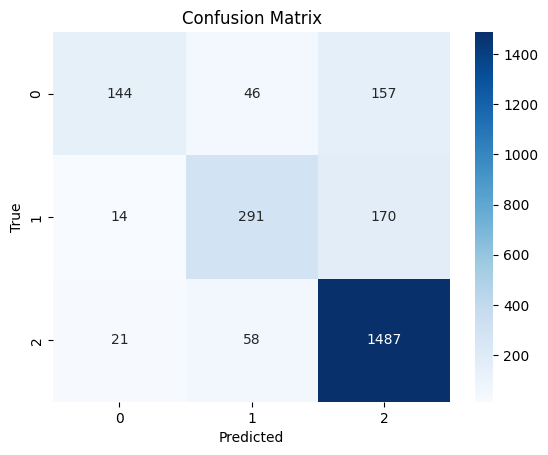

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **HP Tuning RF mode on Ngram & TF-IDF**

In [ ]:
from sklearn.model_selection import GridSearchCV

# Assuming RandomForest parameters to be tuned
param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [20, 40],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 4]
}

# Create a GridSearchCV object
ngram_tfidf_rf_clf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=ngram_tfidf_rf_clf, param_grid=param_grid, cv=3, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters and model
print("Best parameters found: ", grid_search.best_params_)



Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Best parameters found:  {'max_depth': 40, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


# **Ngram & TF-IDF + RF HP tuned**

In [ ]:
# Initialize the Random Forest classifier
ngram_rfidf_rfclf = RandomForestClassifier(n_estimators=200, max_depth = 40,
                                           min_samples_leaf = 1, min_samples_split = 5,random_state=42)

# Train the classifier
ngram_rfidf_rfclf.fit(X_train, y_train)

# Predict the test set
predictions = ngram_rfidf_rfclf.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, predictions)
report = classification_report(y_test, predictions)

print("Accuracy of the model: ", accuracy)
print("Classification Report:\n", report)

Accuracy of the model:  0.6838358458961474
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.05      0.09       347
           1       0.98      0.11      0.19       475
           2       0.68      1.00      0.81      1566

    accuracy                           0.68      2388
   macro avg       0.89      0.38      0.36      2388
weighted avg       0.78      0.68      0.58      2388



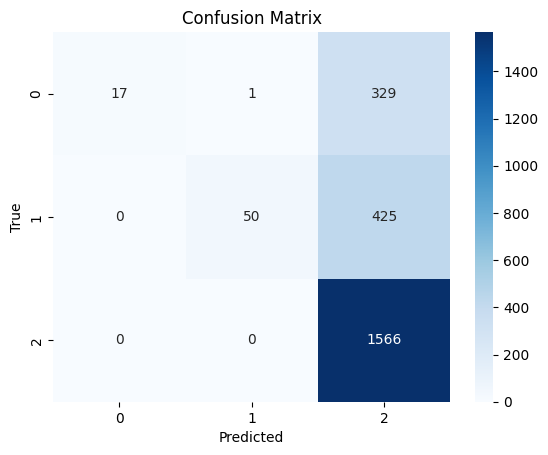

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **Ngram & TF-IDF + DT (base)**

In [ ]:
# Basic DT Classifier model testing

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn import tree

ngram_tfidf_dtclf = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the Decision Tree Classifier
ngram_tfidf_dtclf.fit(X_train, y_train)

# Predict the response for the test dataset
y_pred = ngram_tfidf_dtclf.predict(X_test)

# Evaluating the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6930485762144054
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.08      0.15       347
           1       0.92      0.14      0.25       475
           2       0.68      1.00      0.81      1566

    accuracy                           0.69      2388
   macro avg       0.83      0.41      0.40      2388
weighted avg       0.76      0.69      0.60      2388



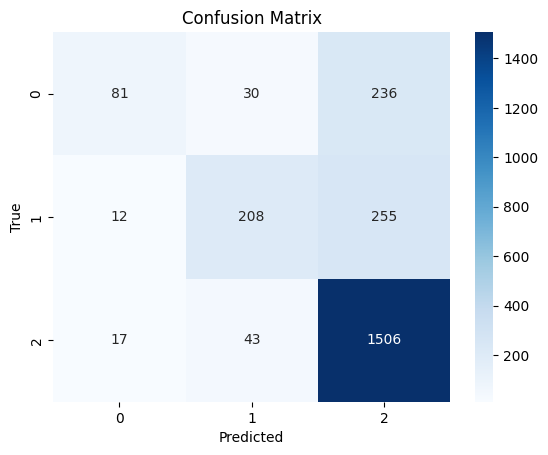

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **HP Tuning DT for Ngram TF-IDF**

In [ ]:
# Hyper tuning DT Classifier training data

dt1 = DecisionTreeClassifier(random_state=42)

# Create the parameter grid
param_grid = {
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Setup the grid search
grid_search = GridSearchCV(estimator=dt1, param_grid=param_grid, cv=5, verbose=1, scoring='accuracy')

# Fit grid search
grid_search.fit(X_train, y_train)

# Best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validated score: ", grid_search.best_score_)



Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-validated score:  0.6560805431186052


# **Train and Test DT (HP Tuned) + Ngram & TF-IDF**

In [ ]:
ngram_tfidf_dtclf = DecisionTreeClassifier(max_depth=20, criterion='gini', min_samples_leaf=1, min_samples_split = 5, random_state=42)

# Train the Decision Tree Classifier using features data
ngram_tfidf_dtclf.fit(X_train, y_train)

# Predict the response for the test dataset
y_pred_dt = ngram_tfidf_dtclf.predict(X_test)

# Evaluating the Model
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.751675041876047
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.23      0.35       347
           1       0.74      0.44      0.55       475
           2       0.75      0.96      0.85      1566

    accuracy                           0.75      2388
   macro avg       0.74      0.54      0.58      2388
weighted avg       0.75      0.75      0.72      2388



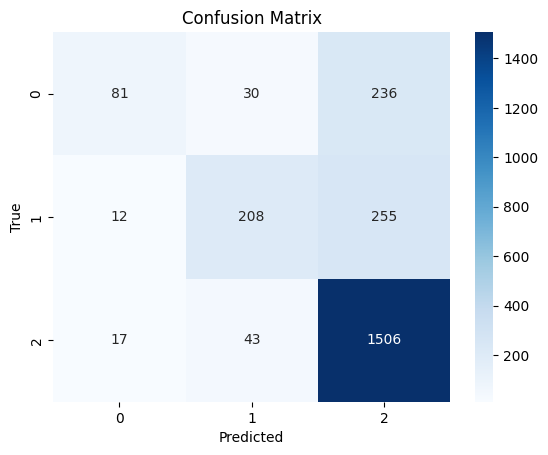

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **Error Analysis**

In [ ]:
import pandas as pd
import numpy as np

# Find misclassified indices
misclassified_indices = np.where(y_pred_dt != y_test)[0]

# Select 50 misclassified samples
num_samples = min(50, len(misclassified_indices))
selected_indices = np.random.choice(misclassified_indices, num_samples, replace=False)

# DataFrame to show the original text with true and predicted labels
misclassified_samples = pd.DataFrame({
    'Text': [test_text[i] for i in selected_indices],
    'True_Label': y_test[selected_indices],
    'Predicted_Label': y_pred_dt[selected_indices]
})

# Display the misclassified examples
print("Misclassified Examples (with Original Text):")
print(misclassified_samples.to_string(index=False))


Misclassified Examples (with Original Text):
                                                                                                                                                                                                     Text  True_Label  Predicted_Label
                                                                                                         [guyana, set, become, top, oil, producer, newly, discovered, offshore, oil, field, insight, via]           1                2
                                                                                                [cme, volatility, new, york, gold, price, impacting, liquidity, london, lbma, cme, stock, marketscreener]           0                2
                                                                                                                                              [activism, rise, japan, firm, go, hostile, investor, speak]           2                1
                               

# **BERT**

# **Load and Prepare the Data**

In [ ]:
pip install transformers datasets torch


  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.19.3-py3-none-manylinux1_x86_64.whl (166.0 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
  Using cached nvidia_nvjitlink_cu12-12.4.127-py3-none-m

In [ ]:
from datasets import load_dataset

# Load dataset
dataset = load_dataset('zeroshot/twitter-financial-news-sentiment')
train_set = dataset['train']
test_set = dataset['validation']

# Prepare the data
X_train = train_set['text']
y_train = train_set['label']
X_test = test_set['text']
y_test = test_set['label']


# **Pre-process Data for BERT**

In [ ]:
# source = https://huggingface.co/transformers/v4.8.2/model_doc/bert.html?highlight=berttokenizer

from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

def encode_data(tokenizer, texts, max_length=512):
    return tokenizer(texts, padding=True, truncation=True, max_length=max_length, return_tensors="pt")

# Tokenize data
train_encodings = encode_data(tokenizer, X_train)
test_encodings = encode_data(tokenizer, X_test)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# **Convert Labels and Encodings to PyTorch Datasets**

In [ ]:
# Source : https://skimai.com/fine-tuning-bert-for-sentiment-analysis/#21_BERT_Tokenizer%C2%B6

from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch

# Convert to tensor
train_labels = torch.tensor(y_train)
test_labels = torch.tensor(y_test)

# dataset
train_dataset = TensorDataset(train_encodings['input_ids'], train_encodings['attention_mask'], train_labels)
test_dataset = TensorDataset(test_encodings['input_ids'], test_encodings['attention_mask'], test_labels)

# Slicing the datasets to take only 1/4 of the data
quarter_train_size = len(train_dataset) // 4
quarter_test_size = len(test_dataset) // 4

# sliced datasets
train_dataset_quarter = TensorDataset(train_dataset.tensors[0][:quarter_train_size],
                                      train_dataset.tensors[1][:quarter_train_size],
                                      train_dataset.tensors[2][:quarter_train_size])
test_dataset_quarter = TensorDataset(test_dataset.tensors[0][:quarter_test_size],
                                     test_dataset.tensors[1][:quarter_test_size],
                                     test_dataset.tensors[2][:quarter_test_size])

# data loader with the sliced datasets
train_loader = DataLoader(train_dataset_quarter, batch_size=8, sampler=RandomSampler(train_dataset_quarter))
test_loader = DataLoader(test_dataset_quarter, batch_size=8, sampler=SequentialSampler(test_dataset_quarter))


# **Training the Model**

In [ ]:
# https://huggingface.co/blog/ray-tune

from transformers import get_scheduler

# optimizer with the PyTorch's AdamW
optimizer = AdamW(model.parameters(), lr=5e-5)

# learning rate scheduler
num_training_steps = len(train_loader) * 3  # number of epochs * number of training batches
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps= (num_training_steps) * 0.1,  # 10% of train steps
    num_training_steps=num_training_steps
)

# training loop
for epoch in range(3):  # Number of epochs
    model.train()
    for batch in train_loader:
        b_input_ids, b_input_mask, b_labels = batch
        model.zero_grad()
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        lr_scheduler.step()  # update the learning rate

    print(f"Loss after epoch {epoch}: {loss.item()}")


Loss after epoch 0: 0.40151098370552063
Loss after epoch 1: 0.0037686056457459927
Loss after epoch 2: 0.002200802555307746


# **Hyperparameter Tuning**

In [ ]:
# source: https://huggingface.co/blog/ray-tune

from transformers import BertTokenizer, BertForSequenceClassification, get_scheduler
import torch
from torch.utils.data import DataLoader
import torch.optim as optim

# Hyperparameter
learning_rates = [1e-5, 3e-5, 5e-5]
fixed_batch_size = 8
num_epochs = 3

# Best hyperparameter tracking
best_loss = float('inf')
best_params = {}

for lr in learning_rates:
    # model and optimizer
    model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)
    optimizer = optim.AdamW(model.parameters(), lr=lr)

    # Learning rate scheduler setup
    num_training_steps = len(train_loader) * num_epochs
    lr_scheduler = get_scheduler(
        "linear",
        optimizer=optimizer,
        num_warmup_steps=int(num_training_steps * 0.1),  # typically 10% of train steps
        num_training_steps=num_training_steps
    )

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            b_input_ids, b_input_mask, b_labels = batch
            model.zero_grad()
            outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            lr_scheduler.step()
            total_loss += loss.item()

        # Average loss across epochs
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch}, LR {lr}, Batch {fixed_batch_size}, Loss: {avg_loss}")

        # Check if this is the best performing set of parameters
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_params = {'learning_rate': lr, 'batch_size': fixed_batch_size}

print(f"Best Parameters: {best_params}, Loss: {best_loss}")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 0, LR 1e-05, Batch 8, Loss: 0.7840683760501469
Epoch 1, LR 1e-05, Batch 8, Loss: 0.4620517025324812
Epoch 2, LR 1e-05, Batch 8, Loss: 0.2785310643447881


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 0, LR 3e-05, Batch 8, Loss: 0.6985469210805701
Epoch 1, LR 3e-05, Batch 8, Loss: 0.32034711127969934
Epoch 2, LR 3e-05, Batch 8, Loss: 0.11771209303205553


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 0, LR 5e-05, Batch 8, Loss: 0.700101731039808
Epoch 1, LR 5e-05, Batch 8, Loss: 0.32263751417385994
Epoch 2, LR 5e-05, Batch 8, Loss: 0.09575043605830533
Best Parameters: {'learning_rate': 5e-05, 'batch_size': 8}, Loss: 0.09575043605830533


# **Re-Training the Model using the best hyperparameters**

In [ ]:
from transformers import get_scheduler
import torch
import torch.optim as optim
from transformers import BertForSequenceClassification, get_scheduler, AdamW

# model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

# optimizer with the PyTorch's AdamW
optimizer = AdamW(model.parameters(), lr=5e-05)

# learning rate scheduler
num_training_steps = len(train_loader) * 3  # number of epochs * number of training batches
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps= (num_training_steps) * 0.1,  # 10% of train steps
    num_training_steps=num_training_steps
)

# training loop
for epoch in range(3):  # Number of epochs
    model.train()
    for batch in train_loader:
        b_input_ids, b_input_mask, b_labels = batch
        model.zero_grad()
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        lr_scheduler.step()  # update the learning rate

    print(f"Loss after epoch {epoch}: {loss.item()}")


/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:521: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Loss after epoch 0: 0.38237541913986206
Loss after epoch 1: 0.07675674557685852
Loss after epoch 2: 0.2140534222126007


# **Evaluate the Model**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Switch model to evaluation mode
model.eval()
predictions, true_labels = [], []

# Predict
for batch in test_loader:
    b_input_ids, b_input_mask, b_labels = batch
    with torch.no_grad():
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
    logits = outputs.logits
    predictions.append(logits.argmax(dim=-1).cpu().numpy())
    true_labels.append(b_labels.cpu().numpy())

# Calculate the accuracy
predictions = np.concatenate(predictions)
true_labels = np.concatenate(true_labels)
print("Test Accuracy:", accuracy_score(true_labels, predictions))
print("Classification Report:\n", classification_report(true_labels, predictions))


Test Accuracy: 0.8726968174204355
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.76      0.75        72
           1       0.83      0.72      0.77       103
           2       0.91      0.93      0.92       422

    accuracy                           0.87       597
   macro avg       0.82      0.80      0.81       597
weighted avg       0.87      0.87      0.87       597



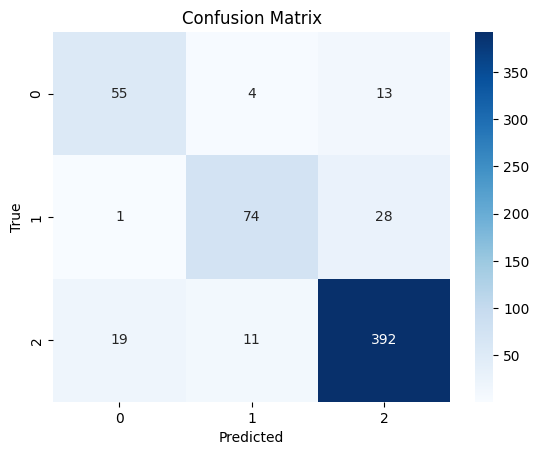

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(true_labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Find misclassified indices
misclassified_indices = np.where(predictions != true_labels)[0]

# Select 50 misclassified samples for analysis
num_samples = min(50, len(misclassified_indices))
selected_indices = np.random.choice(misclassified_indices, num_samples, replace=False)

# Create a DataFrame to show the original text with true and predicted labels
misclassified_samples = pd.DataFrame({
    'Text': [test_text[i] for i in selected_indices],
    'True_Label': true_labels[selected_indices],
    'Predicted_Label': predictions[selected_indices]
})

# Display the misclassified examples
print("Misclassified Examples (with Original Text):")
print(misclassified_samples.to_string(index=False))


Misclassified Examples (with Original Text):
                                                                                                                Text  True_Label  Predicted_Label
                       [transport, london, decided, extend, uber, license, operate, city, statement, transit, offic]           0                2
                                                                      [procter, gamble, look, get, well, healthcare]           2                1
         [fire, broke, overnight, exxon, baton, rouge, oil, refinery, louisiana, halting, production, fifth, bigges]           2                0
                                   [barclays, assigns, chance, study, gilead, antiviral, drug, done, china, succeed]           0                2
                                                                                        [aapl, max, apple, mac, pro]           2                1
                                                         [sale, grounded, boein

# **Save model**

In [ ]:
import os
from transformers import BertForSequenceClassification, AdamW, get_scheduler
import torch

from google.colab import drive
drive.mount('/content/drive')

import os

# base directory
base_dir = '/content/drive/My Drive/NLP/NLP_CW/model/'

# Create the directory if it doesn't exist
if not os.path.exists(base_dir):
    os.makedirs(base_dir, exist_ok=True)
    print("Directory created:", base_dir)
else:
    print("Directory already exists:", base_dir)

model_path = os.path.join(base_dir, 'bert_model.bin')
optimizer_path = os.path.join(base_dir, 'optimizer_state.bin')
scheduler_path = os.path.join(base_dir, 'scheduler_state.bin')

torch.save(model.state_dict(), model_path)
torch.save(optimizer.state_dict(), optimizer_path)
torch.save(lr_scheduler.state_dict(), scheduler_path)



Mounted at /content/drive
Directory already exists: /content/drive/My Drive/NLP/NLP_CW/model/


# **RoBERTa**

In [ ]:
pip install transformers datasets


In [ ]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset, ClassLabel
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Load dataset
dataset = load_dataset('zeroshot/twitter-financial-news-sentiment')
train_set = dataset['train']
test_set = dataset['validation']

# tokenizer and model
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=3)

# Tokenize input texts
def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

train_set = train_set.map(tokenize, batched=True)
test_set = test_set.map(tokenize, batched=True)

# Set to PyTorch
train_set.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_set.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'clas

In [ ]:
# Install accelerate, transformers, and torch
!pip install accelerate -U
!pip install torch transformers[torch] -U


In [ ]:
# https://huggingface.co/blog/Lora-for-sequence-classification-with-Roberta-Llama-Mistral

# Define compute metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {'accuracy': accuracy, 'f1': f1}

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=4,  # Reduced batch size for training
    per_device_eval_batch_size=4,   # Reduced batch size for evaluation
    evaluation_strategy='epoch',
    save_steps=1000,
    logging_dir='./logs',
)

# Initializing Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_set,
    eval_dataset=test_set,
    compute_metrics=compute_metrics,
)

# Train and evaluate the model
trainer.train()
eval_results = trainer.evaluate()

# results
print(f"Evaluation results: {eval_results}")


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.904200,0.879737,0.655779,0.519449
2,0.898700,0.885488,0.655779,0.519449
3,0.732400,0.700976,0.707286,0.670850


Evaluation results: {'eval_loss': 0.7009760737419128, 'eval_accuracy': 0.707286432160804, 'eval_f1': 0.6708497968842296, 'eval_runtime': 17.6405, 'eval_samples_per_second': 135.37, 'eval_steps_per_second': 33.843, 'epoch': 3.0}


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Perform predictions on the test set
predictions = trainer.predict(test_set)
preds = np.argmax(predictions.predictions, axis=-1)

# Generate classification report
report = classification_report(test_set['label'], preds)

# Display classification report
print(report)


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       347
           1       0.42      0.76      0.54       475
           2       0.87      0.85      0.86      1566

    accuracy                           0.71      2388
   macro avg       0.43      0.54      0.47      2388
weighted avg       0.65      0.71      0.67      2388



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
